# k-NN Regression - Theory & Mathematics

> **MLCourse · Machine Learning · supervised · regression**

Classification asks "which label do my neighbors agree on?".
**Regression asks "what NUMBER do my neighbors have?"** - and answers with a
simple average. Here we compute distances, neighbor-averages, the scaling
trap, and the bias/variance meaning of k - all by hand on REAL penguin data
(Palmer Archipelago, via seaborn's CSV mirror).

## What you'll learn
- Euclidean & Manhattan distance between two real rows, computed manually
- A k=3 prediction computed step-by-step (find neighbors → average their target)
- Why unscaled features silently change WHO your neighbors are
- Reading k as the bias↔variance dial for smooth vs jumpy predictions

In [1]:
# Setup: inline plotting, libraries, reproducibility, and data loading.
try:    # programmatic form of the "%matplotlib inline" magic (valid pure Python)
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:   # running as a plain .py script -> nothing to configure
    pass

import numpy as np                  # vector math (distances, means)
import pandas as pd                 # tables
import matplotlib.pyplot as plt     # plots
import seaborn as sns               # prettier statistical plots

from sklearn.preprocessing import StandardScaler      # z-score features
from sklearn.neighbors import KNeighborsRegressor     # the model we dissect
from sklearn.metrics import r2_score                  # goodness-of-fit score

np.random.seed(42)                    # reproducible randomness everywhere
sns.set_theme()                       # seaborn's clean default styling
plt.rcParams["figure.dpi"] = 100      # crisp but light figures

# --- locate the shared data folder by walking UP until we find 02_machine_learning ---
from pathlib import Path
ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent          # keep stepping up (D:\...\MLCourse\02_machine_learning)

# --- download-once helper: reuse the local CSV if it exists, else fetch it ---
import urllib.request
def get_data(fname, url):
    f = ML_ROOT / "data" / fname                       # canonical storage spot
    if not f.exists():                                 # first run on this machine?
        f.write_bytes(urllib.request.urlopen(url).read())  # fetch bytes from the web
        print("downloaded ->", fname)
    else:
        print("using local ->", fname)                 # already cached, skip network
    return pd.read_csv(f)                              # always return a DataFrame

# Real penguins; dropna because a few rows have missing measurements.
pen = get_data("penguins.csv",
               "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv").dropna()
pen = pen.reset_index(drop=True)     # tidy index after dropping rows
print(pen.shape)                     # (rows, columns)

using local -> penguins.csv
(333, 7)


## 1. Distances by hand - two real penguins

Every k-NN decision starts with ONE question: *how far apart are two rows?*
We take two genuine penguins and compute both classic distances with plain numpy.

In [2]:
# Use two numeric features so the math stays visible on paper:
#   bill length (mm) and flipper length (mm).
two = pen[["bill_length_mm", "flipper_length_mm"]].values   # shape (n, 2) numpy array
species = pen["species"].values                             # labels, just for printing
mass = pen["body_mass_g"].values                            # the TARGET we'll predict later

a, b = two[0], two[1]                                       # penguin A = row 0, penguin B = row 1

euclid = np.sqrt(((a - b) ** 2).sum())                      # sqrt of summed squared gaps
manhattan = np.abs(a - b).sum()                             # sum of absolute gaps ("city blocks")

print(f"penguin A ({species[0]}): bill {a[0]:.1f} mm | flipper {a[1]:.1f} mm | mass {mass[0]:.0f} g")
print(f"penguin B ({species[1]}): bill {b[0]:.1f} mm | flipper {b[1]:.1f} mm | mass {mass[1]:.0f} g")
print(f"\nEuclidean d = sqrt({((a - b)**2).sum():.2f}) = {euclid:.3f} mm-units")
print(f"Manhattan d = {' + '.join(f'{v:.1f}' for v in np.abs(a-b))} = {manhattan:.3f}")
print("\n-> Euclidean is sklearn's default (metric='minkowski', p=2); Manhattan (p=1)")
print("   punishes big single-feature gaps LESS, so it is more outlier-tolerant.")

penguin A (Adelie): bill 39.1 mm | flipper 181.0 mm | mass 3750 g
penguin B (Adelie): bill 39.5 mm | flipper 186.0 mm | mass 3800 g

Euclidean d = sqrt(25.16) = 5.016 mm-units
Manhattan d = 0.4 + 5.0 = 5.400

-> Euclidean is sklearn's default (metric='minkowski', p=2); Manhattan (p=1)
   punishes big single-feature gaps LESS, so it is more outlier-tolerant.


## 2. A full prediction by hand - the k=3 neighbor average

Recipe for k-NN regression on a query row `q`:

1. compute $d(q, x_i)$ to every other row
2. keep the indices of the **k smallest** distances
3. predict $\hat{y}(q)=\text{mean}(y_{i_1},...,y_{i_k})$

We hide one real penguin, pretend we don't know its mass, and rebuild that
number from its 3 nearest neighbors.

In [3]:
q_idx = 200                                        # our mystery penguin (row 200)
X_rest = np.delete(two, q_idx, axis=0)             # feature rows WITHOUT the query
mass_rest = np.delete(mass, q_idx, axis=0)         # targets WITHOUT the query
sp_rest = np.delete(species, q_idx)                 # labels WITHOUT the query

dists = np.sqrt(((X_rest - two[q_idx]) ** 2).sum(axis=1))   # distance to EVERY row at once

k = 3                                              # the famous knob
nn = np.argsort(dists)[:k]                         # positions of the 3 closest rows

print(f"query: {species[q_idx]}, bill {two[q_idx][0]:.1f}, flipper {two[q_idx][1]:.1f}, TRUE mass {mass[q_idx]:.0f} g\n")
for rank, i in enumerate(nn, start=1):             # walk the 3 winners, nicest first
    print(f"neighbor {rank}: {sp_rest[i]:<9} bill {X_rest[i][0]:5.1f} | flipper {X_rest[i][1]:5.1f} "
          f"| d={dists[i]:6.2f} | mass {mass_rest[i]:.0f} g")

pred_uniform = mass_rest[nn].mean()                # plain average = weights='uniform'
w = 1.0 / np.maximum(dists[nn], 1e-9)              # closer -> bigger weight (guard vs d=0)
pred_weighted = (mass_rest[nn] * w).sum() / w.sum()  # weighted mean = weights='distance'

print(f"\nuniform average  -> predicted mass = {pred_uniform:.0f} g   (true {mass[q_idx]:.0f} g)")
print(f"distance-weighted -> predicted mass = {pred_weighted:.0f} g   (error shrinks/grows?)")

query: Chinstrap, bill 42.5, flipper 187.0, TRUE mass 3350 g

neighbor 1: Chinstrap bill  42.5 | flipper 187.0 | d=  0.00 | mass 3350 g
neighbor 2: Chinstrap bill  43.2 | flipper 187.0 | d=  0.70 | mass 2900 g
neighbor 3: Chinstrap bill  40.9 | flipper 187.0 | d=  1.60 | mass 3200 g

uniform average  -> predicted mass = 3150 g   (true 3350 g)
distance-weighted -> predicted mass = 3350 g   (error shrinks/grows?)


> 💡 **Pro tip:** `weights="distance"` usually wins when density varies - in
sparse regions its nearest few neighbors dominate instead of being diluted by
farther ones. It rarely LOSES to `"uniform"`, which is why we try both later.

## 3. The scaling trap - raw units decide WHO your neighbors are

Distances compare raw numbers. If bill ranges over ~30 mm and flipper over
~60 mm, flipper gaps are automatically ~4× louder in the squared sum - even
when they matter no more biologically. Standardizing (z-scores) gives every
feature an equal vote. Watch the neighbor set CHANGE.


raw-unit top-3 masses : [np.float64(2900.0), np.float64(3200.0), np.float64(3350.0)]
scaled    top-3 masses: [np.float64(2900.0), np.float64(3350.0), np.float64(4100.0)]

Did scaling change the neighbor set? -> YES


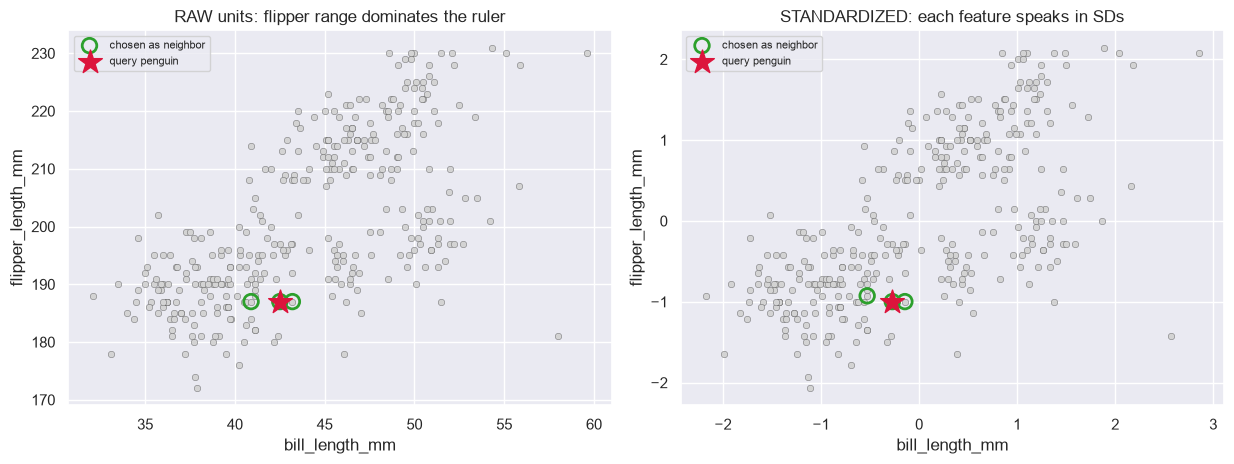

In [4]:
sc = StandardScaler().fit(two)          # learn mean/std of BOTH features
scaled = sc.transform(two)              # now every column: mean 0, std 1

# recompute the k=3 neighborhood of the SAME query penguin, scaled this time
d_scaled = np.sqrt(((np.delete(scaled, q_idx, axis=0) - scaled[q_idx]) ** 2).sum(axis=1))
nn_scaled = np.argsort(d_scaled)[:k]    # positions under the fair ruler

changed = not (set(nn.tolist()) == set(nn_scaled.tolist()))   # did membership flip?
print("\nraw-unit top-3 masses :", sorted(mass_rest[nn].round(0)))
print("scaled    top-3 masses:", sorted(mass_rest[nn_scaled].round(0)))
print(f"\nDid scaling change the neighbor set? -> {'YES' if changed else 'no'}")

# side-by-side picture: query (red star), its raw-neighbors (green circles),
# and its scaled-neighbors (orange squares)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharex=False)
for ax, Xplot, idxs, title in [
        (axes[0], two, nn, "RAW units: flipper range dominates the ruler"),
        (axes[1], scaled, nn_scaled, "STANDARDIZED: each feature speaks in SDs")]:
    ax.scatter(Xplot[:, 0], Xplot[:, 1], s=22, color="lightgray", edgecolor="k", lw=.2)
    ax.scatter(Xplot[idxs, 0], Xplot[idxs, 1], s=110, facecolor="none",
               edgecolor="tab:green", lw=2, label="chosen as neighbor")  # circle winners
    ax.scatter(*Xplot[q_idx], marker="*", s=320, color="crimson", label="query penguin")
    ax.set_xlabel("bill_length_mm"); ax.set_ylabel("flipper_length_mm")
    ax.set_title(title); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

> ⚠️ **Common pitfall:** fitting the scaler on ALL rows before splitting
leaks test information into training. Always fit the scaler on TRAIN only -
easiest way: put `StandardScaler` inside a `Pipeline` (we do exactly that in
the workflow notebook).

## 4. The k dial - bias vs variance you can SEE

- **k = 1**: prediction = single nearest point → jagged staircase that
  memorizes every wobble (**low bias, huge variance**).
- **k → n**: everyone is a neighbor → almost the global mean flatline
  (**high bias, tiny variance**).

One feature (flipper → body mass) makes the effect drawable:

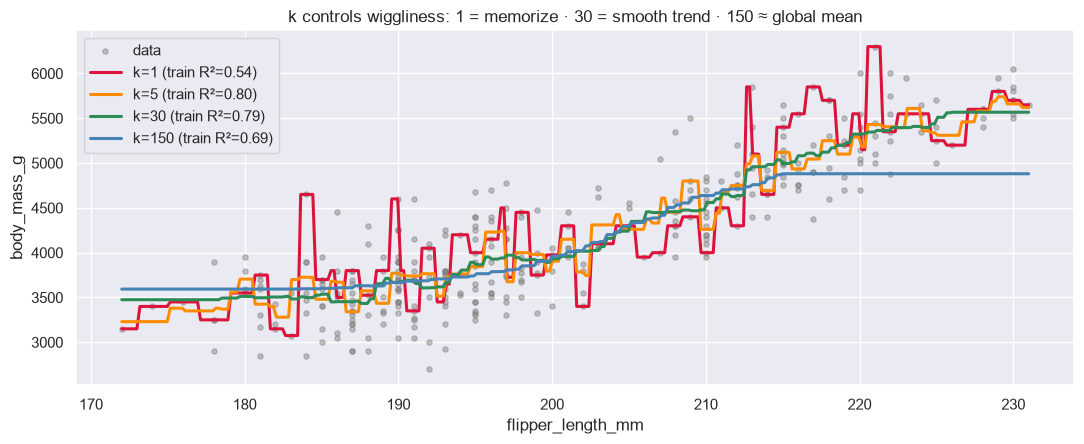

In [5]:
X1 = pen[["flipper_length_mm"]].values        # 1-D feature keeps the plot honest
y1 = pen["body_mass_g"].values                # target in grams
grid = np.linspace(X1.min(), X1.max(), 300).reshape(-1, 1)  # dense x-axis for curves

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.scatter(X1, y1, s=14, alpha=.45, color="gray", label="data")
colors = ["crimson", "darkorange", "seagreen", "steelblue"]
for c, kk in zip(colors, [1, 5, 30, 150]):    # small -> large k, watch it stiffen
    m = KNeighborsRegressor(n_neighbors=kk).fit(X1, y1)     # fit = memorize rows
    ax.plot(grid, m.predict(grid), color=c, lw=2.2,
            label=f"k={kk} (train R²={r2_score(y1, m.predict(X1)):.2f})")
ax.set_xlabel("flipper_length_mm"); ax.set_ylabel("body_mass_g")
ax.set_title("k controls wiggliness: 1 = memorize · 30 = smooth trend · 150 ≈ global mean")
ax.legend(); plt.tight_layout(); plt.show()

### Read-out

| k | train R² | personality |
|---|---|---|
| 1 | ≈ 1.00 (perfect!) | memorized noise - will generalize worst |
| 30 | high but honest | smooth local trend - usually best |
| 150 | visibly low | nearly constant prediction - underfit |

Perfect train R² at k=1 is NOT good news: it is the signature of a model that
cannot be wrong on data it has already seen. Cross-validation (next notebook)
is how we pick k without fooling ourselves.

## Summary & key takeaways

- k-NN regression = **average of the k nearest targets**; classification
  votes, regression averages - same machinery, same distance math.
- Distance-weighted averaging (`weights="distance"`) lets nearby neighbors
  outvote distant ones; a free upgrade worth testing.
- **Scaling decides neighborhoods.** Standardize inside a Pipeline or one
  wide-range feature quietly redraws every neighbor list.
- k is the bias↔variance dial: 1 = memorize, ∞ = global mean. Pick k by CV,
  never by train-set R² (k=1 always "wins" that rigged contest).